<a href="https://colab.research.google.com/github/Jpablo179804/MineriaDatos/blob/main/Parcial3/Digitos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Actividad: Clasificación de Dígitos Manuscritos con Minería de Datos

###Objetivo

Aplicar técnicas de minería de datos y aprendizaje automático para entrenar y evaluar distintos modelos de clasificación usando el dataset Digits (8×8). Posteriormente, se evaluará su desempeño clasificando dígitos manuscritos creados por el estudiante.

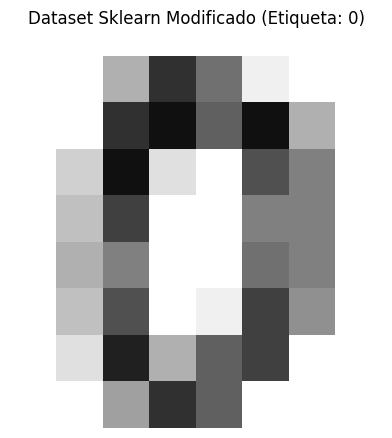

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from PIL import Image

# cargar dat
digits = datasets.load_digits()
X_original = digits.data
y = digits.target

X_escalado = X_original * (255.0 / 16.0)
X_realista = 255.0 - X_escalado

plt.matshow(X_realista[0].reshape(8, 8), cmap='gray', vmin=0, vmax=255)
plt.title(f"Dataset Sklearn Modificado (Etiqueta: {y[0]})")
plt.axis('off')
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X_realista, y, test_size=0.2, random_state=42)

In [40]:
print("Entrenando models")

knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='rbf', gamma='scale')
rf = RandomForestClassifier(n_estimators=100, random_state=42)

knn.fit(X_train, y_train)
svm.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("Exactitud")
print(f"KNN:           {accuracy_score(y_test, knn.predict(X_test)):.4f}")
print(f"SVM:           {accuracy_score(y_test, svm.predict(X_test)):.4f}")
print(f"Random Forest: {accuracy_score(y_test, rf.predict(X_test)):.4f}")

Entrenando models
Exactitud
KNN:           0.9861
SVM:           0.9861
Random Forest: 0.9778


In [41]:
def procesar_foto_simple(nombre_archivo, mostrar=True):
    try:

        img = Image.open(nombre_archivo).convert('L')#escala de grises
        img_res = img.resize((8, 8), Image.Resampling.BILINEAR) #8x8

        img_array = np.array(img_res)

        if mostrar:
            plt.matshow(img_array, cmap='gray', vmin=0, vmax=255)
            plt.title(f"imagen: {nombre_archivo}")
            plt.axis('off')
            plt.show()

        return img_array.reshape(1, -1)

    except FileNotFoundError:
        print(f"Subir archivo {nombre_archivo}")
        return None

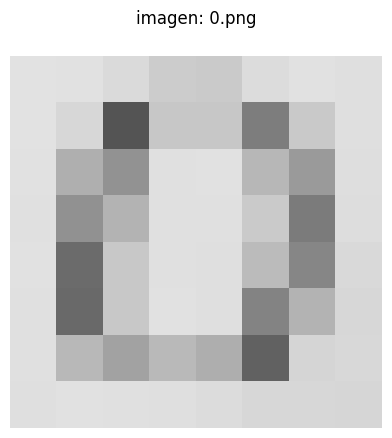


Predicciones para: 0.png 
KNN:           0
SVM:           0
Random Forest: 9


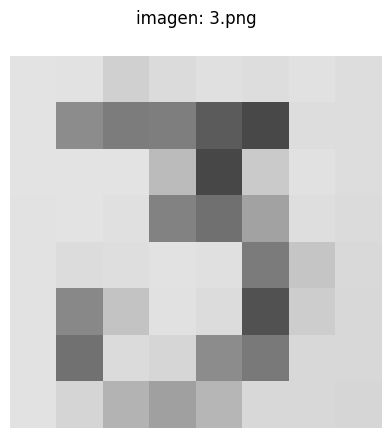


Predicciones para: 3.png 
KNN:           3
SVM:           3
Random Forest: 3


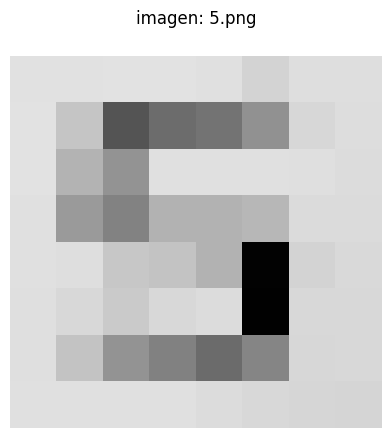


Predicciones para: 5.png 
KNN:           0
SVM:           4
Random Forest: 5


In [42]:
archivos = ['0.png', '3.png', '5.png']

for archivo in archivos:
    datos = procesar_foto_simple(archivo)
    if datos is not None:
        print(f"\nPredicciones para: {archivo} ")
        print(f"KNN:           {knn.predict(datos)[0]}")
        print(f"SVM:           {svm.predict(datos)[0]}")
        print(f"Random Forest: {rf.predict(datos)[0]}")

##Conclusión

####Modelo con mejor desempeño
En las pruebas, los modelos KNN y SVM obtuvieron los mejores resultados, con una exactitud de 98.61%(0.9861), ligeramente por encima de Random Forest.

Al probar con imágenes hechas a mano (0, 3 y 5), KNN y SVM volvieron a destacar, acertando 2 de los 3 números. Ningún modelo fue perfecto, lo que muestra que un buen resultado en entrenamiento no garantiza el mismo desempeño con datos nuevos. Aunque KNN y SVM fueron más consistentes, Random Forest logró identificar correctamente el número más difícil (5).

####Dificultades encontradas
El principal problema fue preparar bien los datos. Hubo una pérdida de calidad al reducir las imágenes a 8x8 píxeles. Además de prepararlas en un formato adecuado para que se pudieran leer sin tanto problema

####Errores observados
•	El número 3 se reconoció siempre correctamente por su forma clara.

•	El 0 a veces se confundió con 9 debido a pequeños detalles en la imagen.

•	El 5 fue el más difícil, su forma puede parecerse a otros números al reducirse tanto en su tamaño

Trabajar con imágenes demasiado pequeñas dificulta el reconocimiento por lo cual es importante preparar bien los datos para entrenar un modelo.

